In [1]:
import sys

sys.path.append("../")

import optuna
import pickle
import scipy

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from qiskit.primitives import BackendEstimatorV2
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator

from utils import objective_scipy, ObjectiveOptuna

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme()

In [3]:
simulator = AerSimulator(method="statevector", device="CPU")
estimator = BackendEstimatorV2(backend=simulator, options=dict(default_precision=1/np.sqrt(4096)))
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)

In [4]:
SCENARIO = "scenarioI"

with open(file=f"../experiments/{SCENARIO}/scenario_info.pkl", mode="rb") as f:
    scenario_info = pickle.load(file=f)

initial_points = np.load(f"../experiments/{SCENARIO}/initial_points.npy")

In [5]:
ansatz = scenario_info["circuit"]
ansatz = pm.run(ansatz)
ising = scenario_info["ising"]
offset = scenario_info["offset"]
optimal_obj_value = scenario_info["optimal_obj_value"]

In [11]:
x0 = initial_points[30]
x0_dict = {f"x[{i}]": value for i, value in enumerate(x0)}

In [12]:
callback_scipy = []
bounds = [(0, 2*np.pi) for _ in range(x0.shape[0])]
result = scipy.optimize.minimize(
    fun=objective_scipy, 
    x0=x0, 
    method="cobyla", 
    bounds=bounds, 
    args=(
        estimator, 
        ansatz, 
        ising, 
        offset, 
        callback_scipy
    ),
    options=dict(maxiter=1000)
)

In [13]:
callback_optuna = []
objective_optuna = ObjectiveOptuna(
    qc=ansatz, 
    estimator=estimator, 
    ising=ising, 
    offset=offset, 
    callback=callback_optuna
)

In [14]:
sampler = optuna.samplers.CmaEsSampler(x0=x0_dict, use_separable_cma=True)
study = optuna.create_study(sampler=sampler)
study.optimize(objective_optuna, n_trials=1000)

[I 2026-06-02 01:42:33,115] A new study created in memory with name: no-name-aa602695-59b1-44a1-b481-9d3bb53262d0
[I 2026-06-02 01:42:33,180] Trial 0 finished with value: 0.01651980032422362 and parameters: {'x[0]': 4.211682660706134, 'x[1]': 2.091169683437967, 'x[2]': 0.26478205001493105, 'x[3]': 4.007707338868664, 'x[4]': 2.653578771296426, 'x[5]': 3.6414990508587923, 'x[6]': 6.08992672899469, 'x[7]': 4.318991455541233, 'x[8]': 1.9335021565490569, 'x[9]': 6.171427321523568, 'x[10]': 5.022698839607149, 'x[11]': 4.538045133530531, 'x[12]': 2.2538546695803485, 'x[13]': 0.9551353076371987, 'x[14]': 0.42244589237052876, 'x[15]': 0.6898527987058722, 'x[16]': 5.112265858669706, 'x[17]': 5.7142443122774615, 'x[18]': 5.958098056360194, 'x[19]': 5.400461799947079, 'x[20]': 2.7266737603855296, 'x[21]': 1.9367300729621943, 'x[22]': 0.27121355614350756, 'x[23]': 1.054814240921133, 'x[24]': 4.810166105032339, 'x[25]': 3.9779164533762366, 'x[26]': 4.4528830293899, 'x[27]': 3.6081793608964388, 'x[28

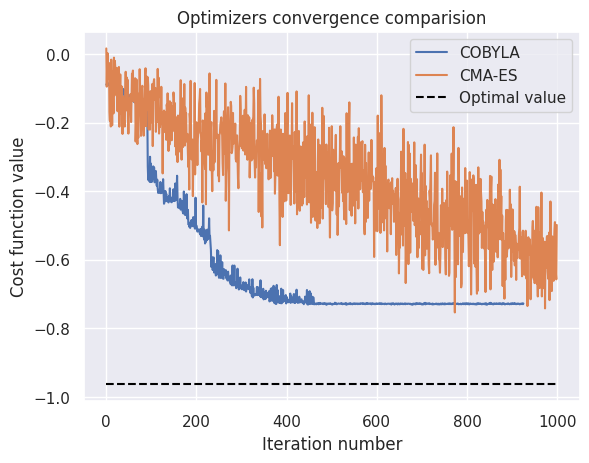

In [16]:
fig, ax = plt.subplots()

ax.plot([*range(len(callback_scipy))], [tp[0] for tp in callback_scipy], linestyle="-", label="COBYLA")
ax.plot([*range(len(callback_optuna))], [tp[0] for tp in callback_optuna], linestyle="-", label="CMA-ES")
ax.hlines(y=optimal_obj_value, xmin=0, xmax=1000, color="black", linestyle="--", label="Optimal value")
ax.set_title("Optimizers convergence comparision")
ax.set_ylabel("Cost function value")
ax.set_xlabel("Iteration number")
ax.legend()

plt.show()